# 30-Day Readmission: Reproduce, Fix, and Audit the Standard Benchmark

The most widely used public readmission benchmark is routinely evaluated with
patient-level leakage and a cohort error. Here we reproduce the standard
approach, fix both, quantify the inflation, and then evaluate the corrected
model properly. The evaluation is the goal here.

This notebook runs top to bottom:
1. Read the data
2. Phase 1: reproduce the standard (leaky) approach → the *before* number
3. Phase 2: fix both issues → the *after* number + headline delta
4. Phase 3: full evaluation (calibration, clinical utility, baselines, fairness, temporal)

All *data* handling lives in `data_prep.ipynb`, pulled in below with `%run`; all
*modelling* is written out here.

In [13]:
#Load the data-prep notebook -> constants + read/cohort/feature/split functions.
%run data_prep.ipynb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

#small, visible helpers used throughout
def train_lightgbm(X, y, cats, tr, te):
    'Fit LightGBM on the train rows; return (model, y_test, y_prob).'
    model = lgb.LGBMClassifier(
        objective='binary', n_estimators=600, learning_rate=0.03, num_leaves=31,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
        min_child_samples=50, random_state=SEED, n_jobs=-1, verbose=-1)
    model.fit(X.iloc[tr], y.iloc[tr], categorical_feature=cats)
    return model, y.iloc[te].to_numpy(), model.predict_proba(X.iloc[te])[:, 1]

def precision_at_k(y_true, y_prob, k):
    k = min(k, len(y_true))
    top = np.argsort(-y_prob)[:k]
    return y_true[top].sum() / k

def calibration_slope_intercept(y_true, y_prob):
    p = np.clip(y_prob, 1e-6, 1 - 1e-6)
    logit = np.log(p / (1 - p)).reshape(-1, 1)
    lr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000).fit(logit, y_true)
    return float(lr.coef_[0][0]), float(lr.intercept_[0])

def net_benefit(y_true, y_prob, thresholds):
    n = len(y_true); nb = []
    for pt in thresholds:
        odds = pt / (1 - pt); pred = y_prob >= pt
        tp = np.sum(pred & (y_true == 1)); fp = np.sum(pred & (y_true == 0))
        nb.append(tp / n - (fp / n) * odds)
    return np.array(nb)

data_prep loaded | 101,766 rows, 71518 patients, 1.42 encounters/patient
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metfo

## 1. Read the data

101,766 encounters but only ~71,500 unique patients (~1.42 encounters/patient)

In [2]:
raw = load_raw()
print('shape:', raw.shape, '| unique patients:', raw[PATIENT_ID].nunique())
raw[['encounter_id', 'patient_nbr', 'discharge_disposition_id', 'readmitted']].head()

shape: (101766, 50) | unique patients: 71518


,encounter_id,patient_nbr,discharge_disposition_id,readmitted
0,2278392,8222157,25,NO
1,149190,55629189,1,>30
2,64410,86047875,1,NO
3,500364,82442376,1,NO
4,16680,42519267,1,NO


## 2. Phase 1: reproduce the standard approach (the *before*)

The leaky setup a lot of published work uses: **naive cohort** (keep everyone),
**stratified split on encounters** (which puts the same patient in train *and*
test), then LightGBM.

ICD-9 grouping in action, then build the cohort + features and measure the leak.

In [3]:
for code in ['250.83', '428', '786', 'V57', '800']:
    print(f'{code:>7} -> {map_icd9_group(code)}')

naive_df, naive_report = build_cohort(raw, exclude_expired_hospice=False)
Xn, cats_n, meta_n = build_features(naive_df)
yn, groups_n = naive_df[TARGET], naive_df[PATIENT_ID]
print('\ncohort:', naive_report)
print('dropped zero-variance:', meta_n['dropped_zero_variance'])

 250.83 -> Diabetes
    428 -> Circulatory
    786 -> Respiratory
    V57 -> Other
    800 -> Injury

cohort: {'n_input': 101766, 'n_excluded_expired_hospice': 0, 'n_output': 101766, 'base_rate_readmit_30d': 0.1116, 'excluded_disposition_ids': []}
dropped zero-variance: ['examide', 'citoglipton']


In [4]:
tr_n, te_n = stratified_split(yn)
leak = patient_overlap(groups_n, tr_n, te_n)
print(f"patient leakage: {leak['n_overlapping_patients']:,} patients in both sides "
      f"({leak['pct_test_patients_leaked']}% of test)")

_, y_test_n, y_prob_n = train_lightgbm(Xn, yn, cats_n, tr_n, te_n)
standard_auroc = roc_auc_score(y_test_n, y_prob_n)
standard_auprc = average_precision_score(y_test_n, y_prob_n)
print(f'STANDARD  AUROC {standard_auroc:.4f} | AUPRC {standard_auprc:.4f}')

patient leakage: 7,001 patients in both sides (38.08% of test)
STANDARD  AUROC 0.6966 | AUPRC 0.2530


## 3. Phase 2: fix both issues (the *after*)

Same model with the same hyperparameters. Two adjustments:
- **Issue 1 fix**: group the split on `patient_nbr` (zero leakage).
- **Issue 2 fix**: drop expired/hospice discharges (they cannot be readmitted).

We keep the corrected `Xc, yc, model_c, ...` as Phase 3 reuses them.

In [5]:
corr_df, corr_report = build_cohort(raw, exclude_expired_hospice=True)
Xc, cats_c, meta_c = build_features(corr_df)
yc, groups_c = corr_df[TARGET], corr_df[PATIENT_ID]
print('cohort:', corr_report)

tr_c, te_c = grouped_split(yc, groups_c)
print('overlapping patients (must be 0):', patient_overlap(groups_c, tr_c, te_c)['n_overlapping_patients'])

model_c, y_test_c, y_prob_c = train_lightgbm(Xc, yc, cats_c, tr_c, te_c)
corrected_auroc = roc_auc_score(y_test_c, y_prob_c)
corrected_auprc = average_precision_score(y_test_c, y_prob_c)
print(f'CORRECTED AUROC {corrected_auroc:.4f} | AUPRC {corrected_auprc:.4f}')
print(f'\nHEADLINE DELTA  AUROC {standard_auroc:.4f} -> {corrected_auroc:.4f} '
      f'(drop {standard_auroc - corrected_auroc:.4f})')

cohort: {'n_input': 101766, 'n_excluded_expired_hospice': 2423, 'n_output': 99343, 'base_rate_readmit_30d': 0.11389, 'excluded_disposition_ids': [11, 13, 14, 19, 20, 21]}
overlapping patients (must be 0): 0
CORRECTED AUROC 0.6781 | AUPRC 0.2448

HEADLINE DELTA  AUROC 0.6966 -> 0.6781 (drop 0.0185)


### The headline chart (standard vs corrected)

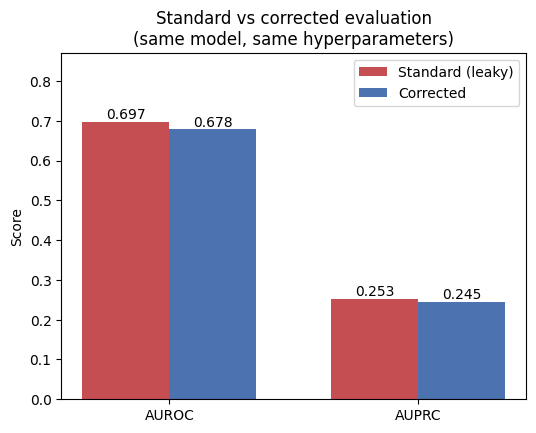

In [6]:
labels = ['AUROC', 'AUPRC']
before = [standard_auroc, standard_auprc]
after = [corrected_auroc, corrected_auprc]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(6, 4.5))
b1 = ax.bar(x - w/2, before, w, label='Standard (leaky)', color='#c44e52')
b2 = ax.bar(x + w/2, after, w, label='Corrected', color='#4c72b0')
ax.bar_label(b1, fmt='%.3f'); ax.bar_label(b2, fmt='%.3f')
ax.set_xticks(x, labels); ax.set_ylabel('Score'); ax.legend()
ax.set_title('Standard vs corrected evaluation\n(same model, same hyperparameters)')
ax.set_ylim(0, max(before + after) * 1.25)
(PROJECT_ROOT / 'assets').mkdir(exist_ok=True)
fig.savefig(PROJECT_ROOT / 'assets' / 'before_after.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Phase 3: full evaluation

### 4a. Which issue does the damage? (2×2: cohort × split)

In [7]:
rows = []
for name, X, y, g in [('naive', Xn, yn, groups_n), ('corrected', Xc, yc, groups_c)]:
    for scheme in ('stratified', 'grouped'):
        tr, te = (stratified_split(y) if scheme == 'stratified' else grouped_split(y, g))
        leaked = patient_overlap(g, tr, te)['n_overlapping_patients']
        _, yt, yp = train_lightgbm(X, y, cats_c, tr, te)
        rows.append({'cohort': name, 'split': scheme, 'auroc': round(roc_auc_score(yt, yp), 4),
                     'leaked_patients': leaked})
pd.DataFrame(rows)

,cohort,split,auroc,leaked_patients
0,naive,stratified,0.6966,7001
1,naive,grouped,0.6802,0
2,corrected,stratified,0.6793,6798
3,corrected,grouped,0.6781,0


### 4b. Calibration

A model with acceptable AUROC and bad calibration is clinically unusable. Ideal
slope is 1, intercept 0.

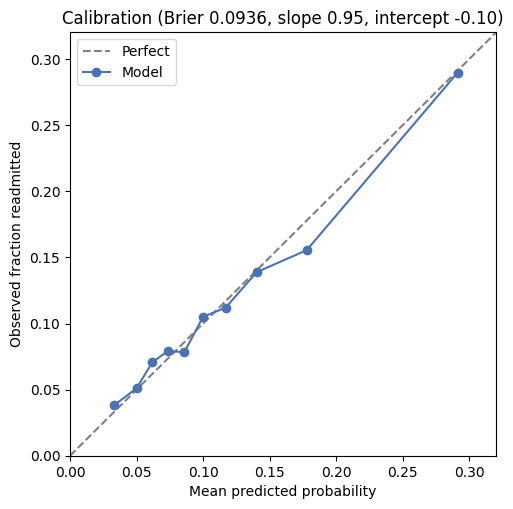

In [8]:
brier = brier_score_loss(y_test_c, y_prob_c)
slope, intercept = calibration_slope_intercept(y_test_c, y_prob_c)
prob_true, prob_pred = calibration_curve(y_test_c, y_prob_c, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
ax.plot(prob_pred, prob_true, 'o-', color='#4c72b0', label='Model')
lim = max(prob_pred.max(), prob_true.max()) * 1.1
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.legend()
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed fraction readmitted')
ax.set_title(f'Calibration (Brier {brier:.4f}, slope {slope:.2f}, intercept {intercept:.2f})')
plt.show()

### 4c. Clinical utility: precision@k and decision-curve analysis

If a care team can call ~50 patients a week, how many of those calls reach
someone who would actually have been readmitted?

precision@25  = 0.600  (lift 5.4x over base rate 0.112)
precision@50  = 0.560  (lift 5.0x over base rate 0.112)
precision@100 = 0.600  (lift 5.4x over base rate 0.112)
precision@200 = 0.570  (lift 5.1x over base rate 0.112)


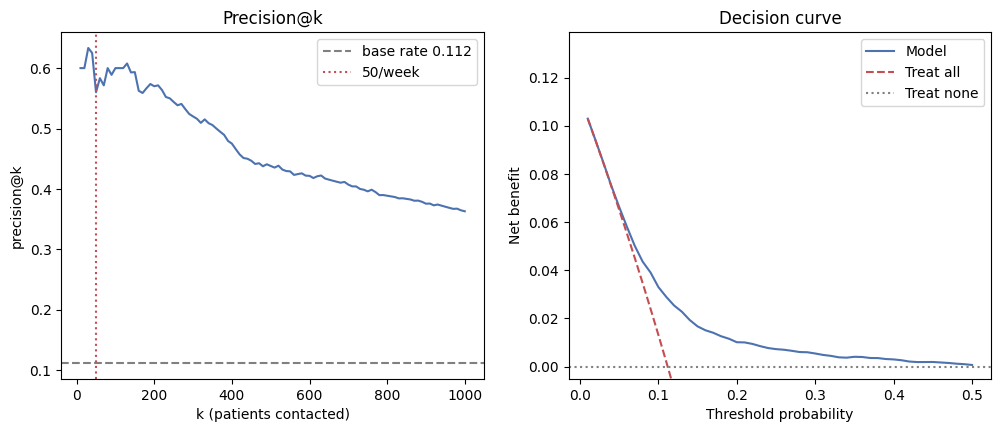

In [9]:
base = y_test_c.mean()
for k in (25, 50, 100, 200):
    p = precision_at_k(y_test_c, y_prob_c, k)
    print(f'precision@{k:<3} = {p:.3f}  (lift {p/base:.1f}x over base rate {base:.3f})')

ks = list(range(10, 1001, 10))
prec = [precision_at_k(y_test_c, y_prob_c, k) for k in ks]
thr = np.linspace(0.01, 0.5, 50)
nb_model = net_benefit(y_test_c, y_prob_c, thr)
nb_all = base - (1 - base) * (thr / (1 - thr))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(ks, prec, color='#4c72b0'); a1.axhline(base, ls='--', color='gray', label=f'base rate {base:.3f}')
a1.axvline(50, ls=':', color='#c44e52', label='50/week'); a1.legend()
a1.set_xlabel('k (patients contacted)'); a1.set_ylabel('precision@k'); a1.set_title('Precision@k')
a2.plot(thr, nb_model, label='Model', color='#4c72b0')
a2.plot(thr, nb_all, '--', label='Treat all', color='#c44e52')
a2.axhline(0, ls=':', color='gray', label='Treat none'); a2.legend()
a2.set_xlabel('Threshold probability'); a2.set_ylabel('Net benefit'); a2.set_title('Decision curve')
a2.set_ylim(min(0, nb_model.min()) - 0.005, nb_model.max() * 1.3 + 0.005)
plt.show()

### 4d. Baselines vs the boosted model

Does gradient boosting actually earn its complexity? Compare a single-feature
baseline and logistic regression against LightGBM.

In [10]:
# Trivial baseline: prior inpatient visits alone.
prior = LogisticRegression(class_weight='balanced', random_state=SEED)
prior.fit(Xc.iloc[tr_c][['number_inpatient']], yc.iloc[tr_c])
pp = prior.predict_proba(Xc.iloc[te_c][['number_inpatient']])[:, 1]

# Logistic regression on all features (one-hot + scaled).
pre = ColumnTransformer([
    ('num', StandardScaler(), meta_c['numeric_features']),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), cats_c)])
logit = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))])
logit.fit(Xc.iloc[tr_c], yc.iloc[tr_c])
lp = logit.predict_proba(Xc.iloc[te_c])[:, 1]

pd.DataFrame([
    {'model': 'number_inpatient alone', 'auroc': round(roc_auc_score(y_test_c, pp), 4),
     'auprc': round(average_precision_score(y_test_c, pp), 4), 'precision@50': round(precision_at_k(y_test_c, pp, 50), 3)},
    {'model': 'logistic regression', 'auroc': round(roc_auc_score(y_test_c, lp), 4),
     'auprc': round(average_precision_score(y_test_c, lp), 4), 'precision@50': round(precision_at_k(y_test_c, lp, 50), 3)},
    {'model': 'lightgbm', 'auroc': round(corrected_auroc, 4),
     'auprc': round(corrected_auprc, 4), 'precision@50': round(precision_at_k(y_test_c, y_prob_c, 50), 3)},
])

,model,auroc,auprc,precision@50
0,number_inpatient alone,0.6022,0.1724,0.56
1,logistic regression,0.6664,0.2199,0.52
2,lightgbm,0.6781,0.2448,0.56


### 4e. Global feature importance: which features drive readmission?

The sections above judge the model overall; this one asks *what it actually
learned*. Two complementary views on the corrected model (`model_c`):

- **LightGBM gain**: the model-native ranking (how much each feature reduced
  loss across all splits). Fast, but magnitude-only and biased toward
  high-cardinality features.
- **SHAP (mean |SHAP|)**: the average impact of each feature on the model's
  output, averaged over patients; the same method Phase 4 uses per-patient.

Expect **prior utilization** (`number_inpatient`, `number_emergency`,
`number_diagnoses`) to dominate; that echoes 4d, where `number_inpatient`
*alone* nearly matched the full model. SHAP magnitude shows *how much* a feature
matters; its *direction* (raises vs lowers risk) is what `genai_audit.ipynb`
inspects patient-by-patient.

/Users/ramibaghdan/Desktop/readmission-eval/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Top 15 features by LightGBM gain:
                 feature         gain
        number_inpatient 26939.119651
discharge_disposition_id 17000.718133
      num_lab_procedures 13619.770895
       medical_specialty 11623.900658
         num_medications 11379.836956
            diag_1_group  7720.648190
        time_in_hospital  7602.528859
              payer_code  6182.082641
        number_diagnoses  5994.002479
                     age  5160.144660
            diag_2_group  5143.393379
            diag_3_group  5110.799421
          num_procedures  4331.005475
        number_emergency  3546.951838
       number_outpatient  2397.695915


/Users/ramibaghdan/Desktop/readmission-eval/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


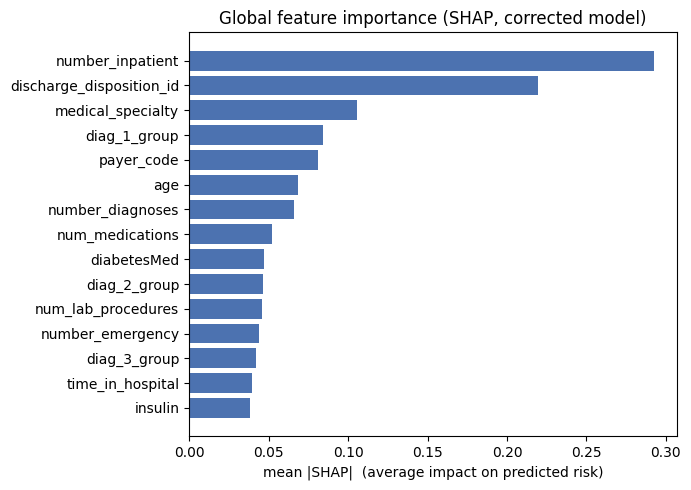

,feature,mean_abs_shap
0,number_inpatient,0.292413
1,discharge_disposition_id,0.219315
2,medical_specialty,0.105656
3,diag_1_group,0.084393
4,payer_code,0.080926
5,age,0.068419
6,number_diagnoses,0.065769
7,num_medications,0.052442
8,diabetesMed,0.047185
9,diag_2_group,0.046751


In [14]:
import shap

#(1)LightGBM gain importance: model-native, instant.
gain_tbl = (pd.DataFrame({'feature': model_c.feature_name_,
                          'gain': model_c.booster_.feature_importance(importance_type='gain')})
            .sort_values('gain', ascending=False).head(15).reset_index(drop=True))
print('Top 15 features by LightGBM gain:')
print(gain_tbl.to_string(index=False))

#(2)SHAP global summary: principled, patient-averaged (sampled for speed).
X_te = Xc.iloc[te_c].reset_index(drop=True)
sample = X_te.sample(min(2000, len(X_te)), random_state=SEED)
sv = shap.TreeExplainer(model_c).shap_values(sample)
if isinstance(sv, list):
    sv = sv[1]
shap_tbl = (pd.DataFrame({'feature': sample.columns,
                          'mean_abs_shap': np.abs(np.asarray(sv)).mean(axis=0)})
            .sort_values('mean_abs_shap', ascending=False).head(15).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(shap_tbl['feature'][::-1], shap_tbl['mean_abs_shap'][::-1], color='#4c72b0')
ax.set_xlabel('mean |SHAP|  (average impact on predicted risk)')
ax.set_title('Global feature importance (SHAP, corrected model)')
fig.tight_layout()
plt.show()
shap_tbl

### 4f. Subgroup/fairness audit

Break AUROC out by sensitive attributes: a model can have fine overall AUROC
while being much worse for some groups.

In [11]:
df_test = corr_df.iloc[te_c].reset_index(drop=True)

def auroc_by_group(attr, min_n=50):
    s = df_test[attr].astype('object').fillna('Missing').to_numpy()
    rows = []
    for val in pd.unique(s):
        m = s == val
        #Skip groups with less than 50 patients and those where re-admitted status is the same for all.
        if m.sum() < min_n or len(np.unique(y_test_c[m])) < 2:
            continue
        rows.append({attr: val, 'n': int(m.sum()), 'base_rate': round(float(y_test_c[m].mean()), 3),
                     'auroc': round(roc_auc_score(y_test_c[m], y_prob_c[m]), 3)})
    return pd.DataFrame(rows).sort_values('n', ascending=False)

for attr in SENSITIVE_FEATURES:
    t = auroc_by_group(attr)
    print(f"{attr}: AUROC gap {t['auroc'].max() - t['auroc'].min():.3f}")
auroc_by_group('payer_code')

race: AUROC gap 0.156
gender: AUROC gap 0.017
age: AUROC gap 0.310
payer_code: AUROC gap 0.173


,payer_code,n,base_rate,auroc
0,Missing,7837,0.117,0.678
1,MC,6303,0.119,0.657
4,HM,1229,0.107,0.698
6,SP,1008,0.095,0.656
2,BC,931,0.088,0.660
5,MD,650,0.115,0.737
9,CP,487,0.105,0.740
3,UN,481,0.079,0.650
10,CM,382,0.099,0.629
11,OG,196,0.122,0.802


### 4g. Temporal validation (encounter-order proxy)

The dataset has no explicit dates, so hold out patients whose first encounter is
latest; a group-safe proxy for dataset shift. This step is just meant to measure model performance on later patients (we expect a drop because of patient mix, coding practices, treatment patterns etc.)

In [12]:
first_enc = corr_df.groupby(PATIENT_ID)[ENCOUNTER_ID].min()
late = set(first_enc[first_enc >= first_enc.quantile(0.8)].index)
is_late = corr_df[PATIENT_ID].isin(late).to_numpy()
tr_t, te_t = np.where(~is_late)[0], np.where(is_late)[0]
_, yt, yp = train_lightgbm(Xc, yc, cats_c, tr_t, te_t)
print(f'temporal-holdout AUROC {roc_auc_score(yt, yp):.4f}  '
      f'(vs {corrected_auroc:.4f} on the random grouped split)')

temporal-holdout AUROC 0.6534  (vs 0.6781 on the random grouped split)


## Takeaways

- **Patient leakage is the dominant trap**: the standard
  evaluation is inflated, not skillful.
- A **single feature (`number_inpatient`) rivals LightGBM on precision@50**;
  gradient boosting barely beats logistic regression.
- Calibration is good, but **subgroup gaps** exist (payer/race/age) and
  performance **drops on later patients**; the standard failure mode of
  deployed clinical models.

Phase 4 (the gen AI explanation audit) lives in `genai_audit.ipynb`.